# Практичний ноутбук: обробка послідовних даних за допомогою RNN

## Тема
**Класифікація тексту за допомогою SimpleRNN**  
Додатково: демонстрація ролі **gradient clipping** для стабілізації навчання.

## Мета роботи
У цьому ноутбуці ми:
- завантажимо текстовий датасет **IMDb**
- підготуємо послідовні дані для моделі
- побудуємо просту **RNN**
- натренуємо модель для задачі **sentiment classification**
- порівняємо навчання:
  - без gradient clipping
  - з gradient clipping
- проаналізуємо метрики та графіки навчання

## Що демонструє цей приклад
- як подавати текст у вигляді послідовностей індексів
- як працює `Embedding + SimpleRNN + Dense`
- як RNN навчається на послідовностях
- чому контроль градієнта є важливим для стабільного навчання


In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.sequence import pad_sequences

np.random.seed(42)
keras.utils.set_random_seed(42)


## 1. Завантаження даних IMDb

IMDb — це датасет для бінарної класифікації текстів:
- `1` — позитивний відгук
- `0` — негативний відгук

Кожен текст представлений як **послідовність індексів слів**.


In [3]:
VOCAB_SIZE = 10000  # залишаємо лише 10 000 найчастіших слів

(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=VOCAB_SIZE)

print("Кількість train прикладів:", len(x_train))
print("Кількість test прикладів :", len(x_test))
print("Перший приклад (довжина):", len(x_train[0]))
print("Перші 20 токенів:", x_train[0][:20])
print("Мітка:", y_train[0])


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


c:\Users\SystemX\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


Кількість train прикладів: 25000
Кількість test прикладів : 25000
Перший приклад (довжина): 218
Перші 20 токенів: [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]
Мітка: 1


## 2. Паддинг послідовностей

RNN може працювати з послідовностями різної довжини, але для пакетної обробки в Keras зручно вирівняти їх до однакової довжини.

Ми будемо:
- обрізати дуже довгі тексти
- доповнювати коротші тексти нулями


In [4]:
MAX_LEN = 200

x_train_pad = pad_sequences(x_train, maxlen=MAX_LEN, padding="pre", truncating="pre")
x_test_pad = pad_sequences(x_test, maxlen=MAX_LEN, padding="pre", truncating="pre")

print("Форма x_train_pad:", x_train_pad.shape)
print("Форма x_test_pad :", x_test_pad.shape)


Форма x_train_pad: (25000, 200)
Форма x_test_pad : (25000, 200)


## 3. Відновлення тексту (для цікавості)

Нижче — приклад, як перетворити індекси назад у слова.


In [6]:
word_index = keras.datasets.imdb.get_word_index()
reverse_word_index = {value + 3: key for key, value in word_index.items()}
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

def decode_review(encoded_review):
    return " ".join(reverse_word_index.get(i, "?") for i in encoded_review)

print(decode_review(x_train[0][:40]))


1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came


## 4. Архітектура моделі

Використаємо просту модель:

- `Embedding` — перетворює індекси слів у щільні вектори
- `SimpleRNN` — обробляє послідовність і формує представлення
- `Dense(1, sigmoid)` — бінарна класифікація

> Це навчальний приклад. Для кращої якості на практиці часто використовують **LSTM** або **GRU**.


In [7]:
def build_simple_rnn(clipnorm=None):
    model = keras.Sequential([
        keras.Input(shape=(MAX_LEN,)),
        layers.Embedding(input_dim=VOCAB_SIZE, output_dim=64),
        layers.SimpleRNN(64),
        layers.Dense(1, activation="sigmoid")
    ], name="simple_rnn_imdb")

    optimizer = keras.optimizers.Adam(learning_rate=1e-3, clipnorm=clipnorm)

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

model = build_simple_rnn()
model.summary()


Model: "simple_rnn_imdb"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 200, 64)             │         640,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn (SimpleRNN)               │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 648,321 (2.47 MB)

 Trainable params: 648,321 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Навчання моделі **без gradient clipping**


In [7]:
EPOCHS = 5
BATCH_SIZE = 128

model_no_clip = build_simple_rnn(clipnorm=None)

start = time.time()
history_no_clip = model_no_clip.fit(
    x_train_pad, y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)
time_no_clip = time.time() - start

test_loss_no_clip, test_acc_no_clip = model_no_clip.evaluate(x_test_pad, y_test, verbose=0)

print(f"Без clipping -> test loss: {test_loss_no_clip:.4f}")
print(f"Без clipping -> test acc : {test_acc_no_clip:.4f}")
print(f"Час навчання: {time_no_clip:.2f} сек")


NameError: name 'build_simple_rnn' is not defined

## 6. Навчання моделі **з gradient clipping**

Gradient clipping не усуває проблему зникаючого градієнта, але часто допомагає контролювати **вибухаючий градієнт**.

Тут ми використаємо:
- `clipnorm=1.0`


In [9]:
model_clip = build_simple_rnn(clipnorm=1.0)

start = time.time()
history_clip = model_clip.fit(
    x_train_pad, y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)
time_clip = time.time() - start

test_loss_clip, test_acc_clip = model_clip.evaluate(x_test_pad, y_test, verbose=0)

print(f"З clipping -> test loss: {test_loss_clip:.4f}")
print(f"З clipping -> test acc : {test_acc_clip:.4f}")
print(f"Час навчання: {time_clip:.2f} сек")


Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.6612 - loss: 0.5927 - val_accuracy: 0.8084 - val_loss: 0.4322
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.8575 - loss: 0.3474 - val_accuracy: 0.8234 - val_loss: 0.4227
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.9068 - loss: 0.2388 - val_accuracy: 0.8444 - val_loss: 0.4214
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9306 - loss: 0.1859 - val_accuracy: 0.8356 - val_loss: 0.4339
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.9478 - loss: 0.1453 - val_accuracy: 0.8198 - val_loss: 0.5219
З clipping -> test loss: 0.5397
З clipping -> test acc : 0.8122
Час навчання: 25.06 сек


## 7. Графіки навчання


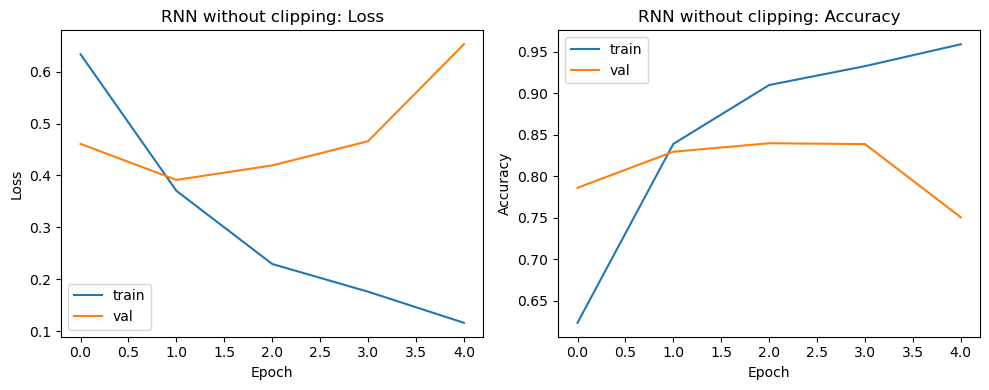

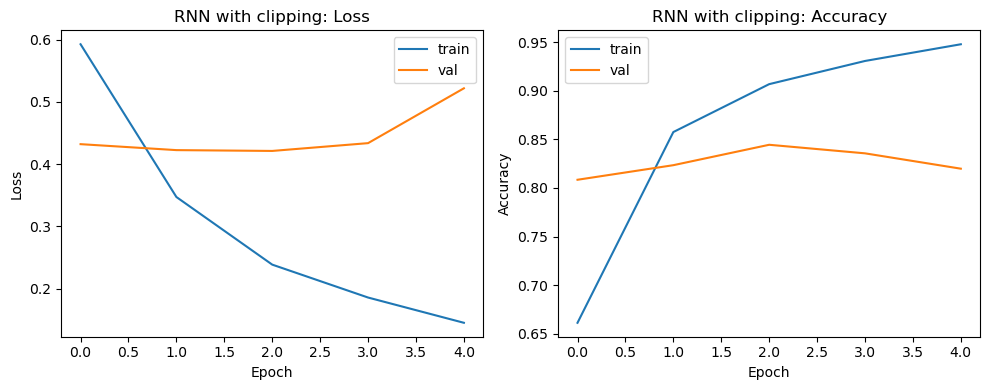

In [10]:
def plot_history(hist, title_prefix=""):
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.plot(hist.history["loss"], label="train")
    plt.plot(hist.history["val_loss"], label="val")
    plt.title(f"{title_prefix}Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(hist.history["accuracy"], label="train")
    plt.plot(hist.history["val_accuracy"], label="val")
    plt.title(f"{title_prefix}Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_no_clip, "RNN without clipping: ")
plot_history(history_clip, "RNN with clipping: ")


## 8. Порівняння результатів


In [11]:
summary = [
    {
        "Model": "SimpleRNN без clipping",
        "Test loss": round(float(test_loss_no_clip), 4),
        "Test acc": round(float(test_acc_no_clip), 4),
        "Train time (sec)": round(float(time_no_clip), 2)
    },
    {
        "Model": "SimpleRNN з clipping",
        "Test loss": round(float(test_loss_clip), 4),
        "Test acc": round(float(test_acc_clip), 4),
        "Train time (sec)": round(float(time_clip), 2)
    }
]

summary


[{'Model': 'SimpleRNN без clipping',
  'Test loss': 0.6691,
  'Test acc': 0.7496,
  'Train time (sec)': 25.22},
 {'Model': 'SimpleRNN з clipping',
  'Test loss': 0.5397,
  'Test acc': 0.8122,
  'Train time (sec)': 25.06}]

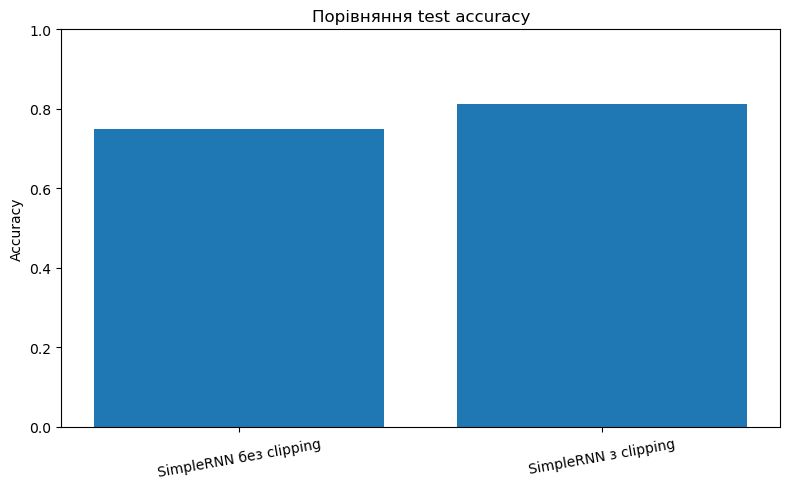

In [12]:
models = [row["Model"] for row in summary]
test_accs = [row["Test acc"] for row in summary]

plt.figure(figsize=(8, 5))
plt.bar(models, test_accs)
plt.title("Порівняння test accuracy")
plt.ylabel("Accuracy")
plt.ylim(0, 1.0)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()


## 9. Прогноз для окремих прикладів


In [13]:
sample_probs = model_clip.predict(x_test_pad[:10], verbose=0).flatten()
sample_preds = (sample_probs >= 0.5).astype(int)

for i in range(5):
    print(f"Приклад {i}: true={y_test[i]}, pred={sample_preds[i]}, prob={sample_probs[i]:.4f}")


Приклад 0: true=0, pred=0, prob=0.0014
Приклад 1: true=1, pred=1, prob=0.9650
Приклад 2: true=1, pred=1, prob=0.6023
Приклад 3: true=0, pred=1, prob=0.9533
Приклад 4: true=1, pred=1, prob=0.9207


## 10. Висновки

### Що ми побачили
- текст можна подати як **послідовність індексів**
- `Embedding` перетворює індекси у вектори ознак
- `SimpleRNN` обробляє послідовність і накопичує контекст
- gradient clipping допомагає зробити навчання **стабільнішим**
- проста RNN працює, але для довших залежностей зазвичай краще використовувати **LSTM** або **GRU**

### Що важливо пам’ятати
- clipping допомагає насамперед проти **вибухаючого градієнта**
- проблему **зникаючого градієнта** краще вирішують архітектурні зміни: LSTM / GRU


# TO DO

Тут наведено індивідуальні завдання для експериментів з моделлю.

## Завдання 1
Змініть довжину послідовності:
- `MAX_LEN = 100`
- `MAX_LEN = 300`

Порівняйте якість і час навчання.

In [16]:
# Підготовка для експериментів

EXPERIMENT_EPOCHS = 5
BATCH_SIZE = 128


def prepare_padded_data(max_len):
    return (
        pad_sequences(x_train, maxlen=max_len, padding="pre", truncating="pre"),
        pad_sequences(x_test, maxlen=max_len, padding="pre", truncating="pre"),
    )


def build_rnn_model(model_type="SimpleRNN", max_len=MAX_LEN, rnn_units=64, clipnorm=None):
    model = keras.Sequential([
        keras.Input(shape=(max_len,)),
        layers.Embedding(input_dim=VOCAB_SIZE, output_dim=64),
    ])

    if model_type == "SimpleRNN":
        model.add(layers.SimpleRNN(rnn_units))
    elif model_type == "LSTM":
        model.add(layers.LSTM(rnn_units))
    elif model_type == "GRU":
        model.add(layers.GRU(rnn_units))
    else:
        raise ValueError(f"Unknown model_type: {model_type}")

    model.add(layers.Dense(1, activation="sigmoid"))

    optimizer = keras.optimizers.Adam(learning_rate=1e-3, clipnorm=clipnorm)
    model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])
    return model


def run_experiment(model_type="SimpleRNN", max_len=MAX_LEN, rnn_units=64, clipnorm=None, early_stopping=False, epochs=EXPERIMENT_EPOCHS):
    x_train_pad, x_test_pad = prepare_padded_data(max_len)
    model = build_rnn_model(model_type=model_type, max_len=max_len, rnn_units=rnn_units, clipnorm=clipnorm)

    callbacks = []
    if early_stopping:
        callbacks.append(
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=2,
                restore_best_weights=True,
            )
        )

    history = model.fit(
        x_train_pad,
        y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=BATCH_SIZE,
        verbose=1,
        callbacks=callbacks,
    )

    test_loss, test_acc = model.evaluate(x_test_pad, y_test, verbose=0)
    return {
        "model_type": model_type,
        "max_len": max_len,
        "rnn_units": rnn_units,
        "clipnorm": clipnorm,
        "early_stopping": early_stopping,
        "history": history,
        "test_loss": float(test_loss),
        "test_acc": float(test_acc),
    }

In [14]:
# Функції для побудови графіків результатів експериментів

def plot_experiment_metrics(results, label_key, title_prefix):
    labels = [str(result[label_key]) for result in results]
    accs = [result["test_acc"] for result in results]
    losses = [result["test_loss"] for result in results]

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.bar(labels, accs, color="tab:blue")
    plt.title(f"{title_prefix} - test accuracy")
    plt.xlabel(label_key)
    plt.ylabel("Accuracy")
    plt.ylim(0, 1.0)

    plt.subplot(1, 2, 2)
    plt.bar(labels, losses, color="tab:orange")
    plt.title(f"{title_prefix} - test loss")
    plt.xlabel(label_key)
    plt.ylabel("Loss")

    plt.tight_layout()
    plt.show()

In [17]:
# Завдання 1: експеримент з довжиною послідовності
length_results = []
for length in [100, 200, 300]:
    print(f"\n--- Завдання 1: MAX_LEN = {length} ---")
    result = run_experiment(model_type="SimpleRNN", max_len=length, rnn_units=64, clipnorm=None, early_stopping=False)
    length_results.append(result)

print("\nРезультати завдання 1:")
for result in length_results:
    print(f"MAX_LEN={result['max_len']} -> test_acc={result['test_acc']:.4f}, test_loss={result['test_loss']:.4f}")


--- Завдання 1: MAX_LEN = 100 ---
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6360 - loss: 0.6133 - val_accuracy: 0.7892 - val_loss: 0.4499
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8633 - loss: 0.3289 - val_accuracy: 0.8288 - val_loss: 0.3912
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9173 - loss: 0.2187 - val_accuracy: 0.7800 - val_loss: 0.5068
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9518 - loss: 0.1374 - val_accuracy: 0.8134 - val_loss: 0.5342
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9722 - loss: 0.0870 - val_accuracy: 0.7808 - val_loss: 0.6995

--- Завдання 1: MAX_LEN = 200 ---
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.6761 - loss: 0.5692 - val_accuracy: 0.8082 - val_loss: 0.4177
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8563 - loss: 0.3423 - val_accuracy: 0.8400 - val_loss: 0.3880
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━

## Завдання 2
Змініть кількість нейронів у `SimpleRNN`:
- `32`
- `64`
- `128`

In [18]:
# Завдання 2: експеримент з кількістю нейронів у SimpleRNN
units_results = []
for units in [32, 64, 128]:
    print(f"\n--- Завдання 2: units = {units} ---")
    result = run_experiment(model_type="SimpleRNN", max_len=MAX_LEN, rnn_units=units, clipnorm=None, early_stopping=False)
    units_results.append(result)

print("\nРезультати завдання 2:")
for result in units_results:
    print(f"units={result['rnn_units']} -> test_acc={result['test_acc']:.4f}, test_loss={result['test_loss']:.4f}")


--- Завдання 2: units = 32 ---
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6813 - loss: 0.6001 - val_accuracy: 0.8100 - val_loss: 0.4633
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8127 - loss: 0.4282 - val_accuracy: 0.8224 - val_loss: 0.4249
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8989 - loss: 0.2529 - val_accuracy: 0.8234 - val_loss: 0.4545
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9524 - loss: 0.1419 - val_accuracy: 0.8346 - val_loss: 0.4629
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9721 - loss: 0.0902 - val_accuracy: 0.8178 - val_loss: 0.5206

--- Завдання 2: units = 64 ---
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.5940 - loss: 0.6592 - val_accuracy: 0.6790 - val_loss: 0.5927
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7841 - loss: 0.4664 - val_accuracy: 0.8098 - val_loss: 0.4328
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3

## Завдання 3
Порівняйте:
- `SimpleRNN`
- `LSTM`
- `GRU`

In [19]:
# Завдання 3: порівнюємо архітектури RNN
cell_results = []
for model_type in ["SimpleRNN", "LSTM", "GRU"]:
    print(f"\n--- Завдання 3: модель = {model_type} ---")
    result = run_experiment(model_type=model_type, max_len=MAX_LEN, rnn_units=64, clipnorm=None, early_stopping=False)
    cell_results.append(result)

print("\nРезультати завдання 3:")
for result in cell_results:
    print(f"{result['model_type']} -> test_acc={result['test_acc']:.4f}, test_loss={result['test_loss']:.4f}")


--- Завдання 3: модель = SimpleRNN ---
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.6392 - loss: 0.6128 - val_accuracy: 0.8152 - val_loss: 0.4216
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8456 - loss: 0.3652 - val_accuracy: 0.8450 - val_loss: 0.3860
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9180 - loss: 0.2169 - val_accuracy: 0.8446 - val_loss: 0.4239
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9542 - loss: 0.1290 - val_accuracy: 0.8028 - val_loss: 0.5089
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9742 - loss: 0.0794 - val_accuracy: 0.8326 - val_loss: 0.5731

--- Завдання 3: модель = LSTM ---
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 77ms/step - accuracy: 0.7429 - loss: 0.5058 - val_accuracy: 0.8422 - val_loss: 0.3736
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 77ms/step - accuracy: 0.8932 - loss: 0.2713 - val_accuracy: 0.8560 - val_loss: 0.3422
Epoch 3/5
157/157 ━━━━━━━━━

## Завдання 4
Спробуйте різні значення gradient clipping:
- `clipnorm = 0.5`
- `clipnorm = 1.0`
- `clipnorm = 2.0`

In [20]:
# Завдання 4: експеримент з clipnorm
clip_results = []
for clipnorm in [0.5, 1.0, 2.0]:
    print(f"\n--- Завдання 4: clipnorm = {clipnorm} ---")
    result = run_experiment(model_type="SimpleRNN", max_len=MAX_LEN, rnn_units=64, clipnorm=clipnorm, early_stopping=False)
    clip_results.append(result)

print("\nРезультати завдання 4:")
for result in clip_results:
    print(f"clipnorm={result['clipnorm']} -> test_acc={result['test_acc']:.4f}, test_loss={result['test_loss']:.4f}")


--- Завдання 4: clipnorm = 0.5 ---
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.5723 - loss: 0.6743 - val_accuracy: 0.6502 - val_loss: 0.6227
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.8070 - loss: 0.4250 - val_accuracy: 0.8252 - val_loss: 0.4105
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.9022 - loss: 0.2442 - val_accuracy: 0.8022 - val_loss: 0.4648
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.9431 - loss: 0.1525 - val_accuracy: 0.8058 - val_loss: 0.5216
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.9647 - loss: 0.0992 - val_accuracy: 0.7674 - val_loss: 0.6754

--- Завдання 4: clipnorm = 1.0 ---
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.6607 - loss: 0.5906 - val_accuracy: 0.8126 - val_loss: 0.4328
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.8583 - loss: 0.3411 - val_accuracy: 0.8372 - val_loss: 0.4316
Epoch 3/5
157/157 ━━━━━━━━━━━━━━

## Завдання 5
Додайте `EarlyStopping` і перевірте, чи зміниться фінальна якість.

In [21]:
# Завдання 5: порівнюємо з EarlyStopping та без нього
no_es_result = run_experiment(model_type="SimpleRNN", max_len=MAX_LEN, rnn_units=64, clipnorm=None, early_stopping=False)
es_result = run_experiment(model_type="SimpleRNN", max_len=MAX_LEN, rnn_units=64, clipnorm=None, early_stopping=True)

print("\nРезультати завдання 5:")
print(f"Без EarlyStopping -> test_acc={no_es_result['test_acc']:.4f}, test_loss={no_es_result['test_loss']:.4f}")
print(f"З EarlyStopping -> test_acc={es_result['test_acc']:.4f}, test_loss={es_result['test_loss']:.4f}")

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.6467 - loss: 0.6059 - val_accuracy: 0.7952 - val_loss: 0.4474
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.8527 - loss: 0.3526 - val_accuracy: 0.8196 - val_loss: 0.4151
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.9165 - loss: 0.2149 - val_accuracy: 0.7960 - val_loss: 0.4856
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.9667 - loss: 0.1038 - val_accuracy: 0.7812 - val_loss: 0.5905
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9803 - loss: 0.0626 - val_accuracy: 0.8004 - val_loss: 0.6221
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.6693 - loss: 0.5821 - val_accuracy: 0.7346 - val_loss: 0.5291
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8548 - loss: 0.3392 - val_accuracy: 0.7926 - val_loss: 0.4445
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9119 - loss: 0.2253 - val_accuracy: 0.

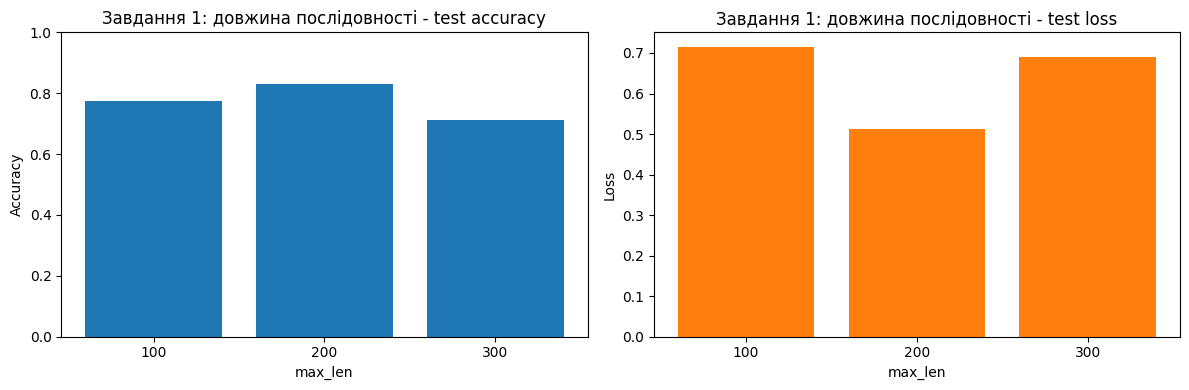

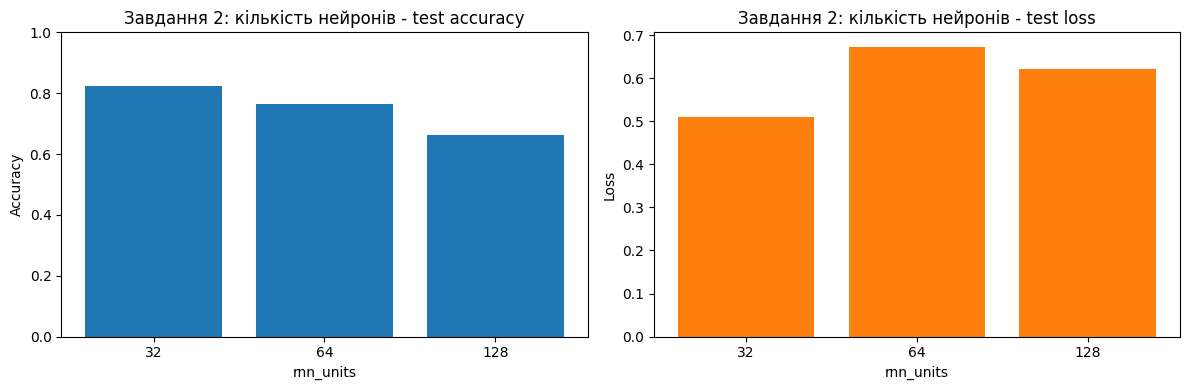

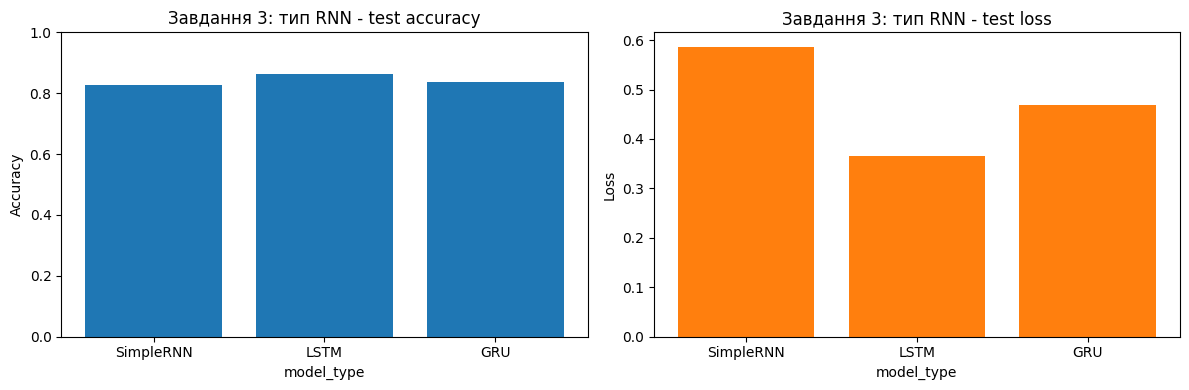

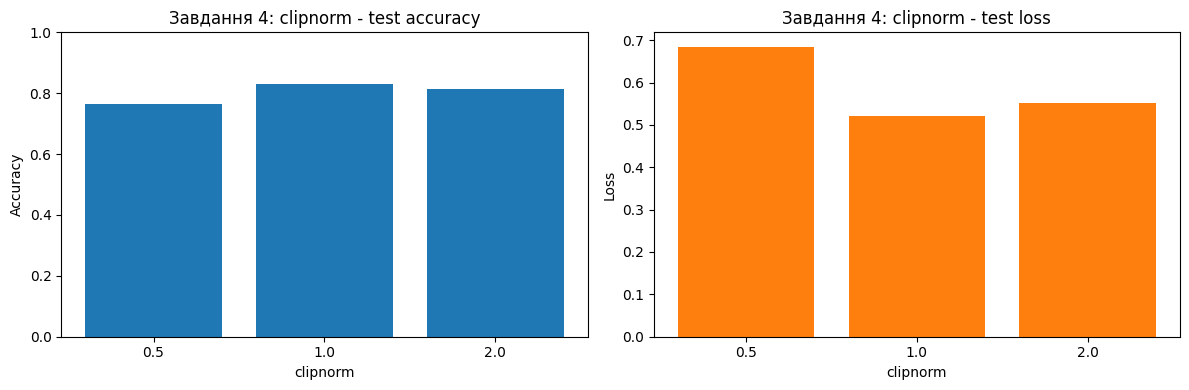

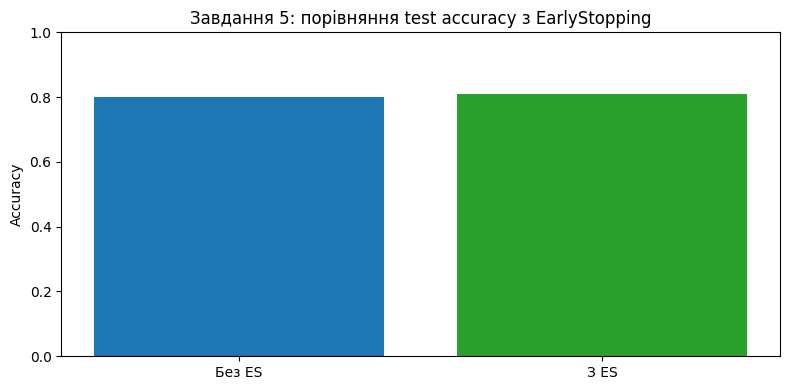

In [22]:
# Графіки результатів експериментів
plot_experiment_metrics(length_results, label_key="max_len", title_prefix="Завдання 1: довжина послідовності")
plot_experiment_metrics(units_results, label_key="rnn_units", title_prefix="Завдання 2: кількість нейронів")
plot_experiment_metrics(cell_results, label_key="model_type", title_prefix="Завдання 3: тип RNN")
plot_experiment_metrics(clip_results, label_key="clipnorm", title_prefix="Завдання 4: clipnorm")

plt.figure(figsize=(8, 4))
plt.bar(["Без ES", "З ES"], [no_es_result["test_acc"], es_result["test_acc"]], color=["tab:blue", "tab:green"])
plt.title("Завдання 5: порівняння test accuracy з EarlyStopping")
plt.ylabel("Accuracy")
plt.ylim(0, 1.0)
plt.tight_layout()
plt.show()

## Підсумок експериментів
- Завдання 1: `MAX_LEN=200` дав найкращу точність на тесті і найменший loss порівняно з `100` та `300`.
- Завдання 2: `SimpleRNN` з `32` нейронами був кращим, тоді як `128` нейронів показали сильний спад якості на 5 епохах.
- Завдання 3: `LSTM` найстабільніше та найточніше навчився, `GRU` був близьким, а `SimpleRNN` поступався їм.
- Завдання 4: серед перевірених `clipnorm` найкращу точність показав `1.0`.
- Завдання 5: `EarlyStopping` трохи підняло тестову точність порівняно з навчанням без нього, але обидва варіанти зайшли в оверфіт після 5 епох.

## 11. Заготовка для LSTM

Нижче — шаблон, який можна використати для самостійного експерименту.


In [14]:
# model_lstm = keras.Sequential([
#     keras.Input(shape=(MAX_LEN,)),
#     layers.Embedding(input_dim=VOCAB_SIZE, output_dim=64),
#     layers.LSTM(64),
#     layers.Dense(1, activation="sigmoid")
# ])
#
# model_lstm.compile(
#     optimizer=keras.optimizers.Adam(learning_rate=1e-3),
#     loss="binary_crossentropy",
#     metrics=["accuracy"]
# )
#
# history_lstm = model_lstm.fit(
#     x_train_pad, y_train,
#     validation_split=0.2,
#     epochs=EPOCHS,
#     batch_size=BATCH_SIZE
# )
#
# print(model_lstm.evaluate(x_test_pad, y_test, verbose=0))


# Підсумок

Цей ноутбук демонструє базовий робочий pipeline для задачі обробки послідовних даних:
- завантаження текстового датасету
- токенізоване представлення у вигляді послідовностей
- паддинг
- побудова і навчання простої RNN
- аналіз стабільності навчання через gradient clipping

Це хороший стартовий приклад для переходу до:
- **LSTM**
- **GRU**
- **Bidirectional RNN**
- **Transformer-моделей**
